# Inexlink — Sprint 6: Model Benchmarking & Upgrade
**Phase 2 | Sprint 6 | Tasks 2.1 & 2.2**

**Objective:** Benchmark tuned Random Forest and XGBoost models against the Phase 1 Ridge Regression baseline. Identify the best candidate model for real data integration in Sprint 7.

**Sprint 6 Context:** Real Inexlink sales data is still pending delivery. This notebook prepares the full model pipeline so the team can immediately retrain on real data the moment it arrives (Sprint 7 / Track B).

**Sprint 10 Update:** Log-transform applied to target variable via `TransformedTargetRegressor`. The multiplicative structure of the time-to-sale data generating process means `log(t)` is linearly related to features, improving Ridge MAE from 6.42 → 5.97 days. Pipelines are unchanged externally — `predict()` still returns days directly.

---
| Task | Owner | Status |
|------|-------|--------|
| 2.1 Random Forest build & benchmarking | Deep | ✅ Complete |
| 2.2 XGBoost build & benchmarking | Deep | ✅ Complete |
| Sprint 10: Log-transform upgrade | Deep | ✅ Complete |

## 1. Imports & Setup

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
import xgboost as xgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('✅ All libraries loaded successfully')
print(f'   scikit-learn, xgboost {xgb.__version__}, pandas {pd.__version__}')

✅ All libraries loaded successfully
   scikit-learn, xgboost 3.2.0, pandas 2.3.2


## 2. Data Generation
Using the same synthetic dataset generator from Phase 1 (seed=42) to ensure a fair apples-to-apples comparison against the Phase 1 Ridge baseline.

The dataset is saved to `../data/synthetic_dataset.csv` for reproducibility and to support the model retraining guide in the Technical Documentation Package.

In [2]:
def generate_mining_data(n_samples=2000, seed=42):
    np.random.seed(seed)
    equipment_types  = ['Excavator', 'Dump Truck', 'Bulldozer', 'Wheel Loader', 'Crusher', 'Conveyor System']
    eq_weights       = [0.25, 0.20, 0.15, 0.15, 0.15, 0.10]
    manufacturers    = ['Caterpillar', 'Komatsu', 'Liebherr', 'Volvo', 'Hitachi', 'JCB', 'Generic']
    mfr_weights      = [0.30, 0.20, 0.15, 0.10, 0.10, 0.10, 0.05]
    conditions       = ['Excellent', 'Good', 'Fair', 'Needs Repair']
    locations        = ['Western Australia', 'Queensland', 'New South Wales',
                        'Alberta Canada', 'Nevada USA', 'Chile', 'South Africa']
    seller_types     = ['Mining Company', 'Equipment Dealer', 'Rental Company', 'Construction Company']

    base_values = {'Excavator': 450000, 'Dump Truck': 380000, 'Bulldozer': 520000,
                   'Wheel Loader': 320000, 'Crusher': 800000, 'Conveyor System': 1200000}
    base_hours  = {'Excavator': 2000, 'Dump Truck': 3000, 'Bulldozer': 1800,
                   'Wheel Loader': 2200, 'Crusher': 4000, 'Conveyor System': 6000}
    mfr_mult    = {'Caterpillar': 1.2, 'Komatsu': 1.15, 'Liebherr': 1.1,
                   'Volvo': 1.05, 'Hitachi': 1.0, 'JCB': 0.95, 'Generic': 0.8}
    cond_price  = {'Excellent': 0.9, 'Good': 0.75, 'Fair': 0.6, 'Needs Repair': 0.4}
    cond_time   = {'Excellent': 0.7, 'Good': 0.9, 'Fair': 1.2, 'Needs Repair': 1.8}
    demand_mult = {'Excavator': 0.8, 'Dump Truck': 0.9, 'Bulldozer': 1.0,
                   'Wheel Loader': 0.85, 'Crusher': 1.2, 'Conveyor System': 1.4}
    seller_time = {'Mining Company': 0.9, 'Equipment Dealer': 0.8,
                   'Rental Company': 1.0, 'Construction Company': 1.1}

    records = []
    for _ in range(n_samples):
        eq    = np.random.choice(equipment_types, p=eq_weights)
        mfr   = np.random.choice(manufacturers, p=mfr_weights)
        cond  = np.random.choice(conditions, p=[0.15, 0.45, 0.30, 0.10])
        age   = min(np.random.exponential(8) + 1, 25)
        hrs   = age * base_hours[eq] * np.random.uniform(0.7, 1.3)
        orig  = base_values[eq] * mfr_mult[mfr] * np.random.uniform(0.8, 1.2)
        price = orig * (0.92 ** age) * cond_price[cond] * np.random.uniform(0.9, 1.1)
        loc   = np.random.choice(locations)
        sel   = np.random.choice(seller_types, p=[0.4, 0.3, 0.2, 0.1])
        mon   = np.random.randint(1, 13)
        maint = np.random.choice([True, False], p=[0.7, 0.3])
        warr  = np.random.choice([True, False], p=[0.3, 0.7])
        photos = max(1, np.random.poisson(8))
        desc   = max(50, min(np.random.normal(200, 50), 500))

        base_t = 90
        ratio  = price / (orig * 0.6)
        t = base_t * np.exp(ratio - 1) * 0.5 * demand_mult[eq] * cond_time[cond]
        t *= (1.0 + 0.1 * np.sin(2 * np.pi * mon / 12)) * np.random.uniform(0.9, 1.1)
        t *= seller_time[sel]
        if maint:      t *= 0.85
        if warr:       t *= 0.80
        if photos > 10: t *= 0.90
        if desc > 300:  t *= 0.95
        t *= np.random.lognormal(0, 0.3)
        t = max(7, min(t, 730))

        records.append({
            'equipment_type': eq, 'manufacturer': mfr, 'condition': cond,
            'age_years': round(age, 1), 'operating_hours': round(hrs),
            'original_value': round(orig), 'listing_price': round(price),
            'location': loc, 'seller_type': sel,
            'has_maintenance_records': maint, 'has_warranty': warr,
            'photos_count': photos, 'description_length': round(desc),
            'listing_month': mon,
            'price_to_original_ratio': round(price / orig, 3),
            'hours_per_year': round(hrs / age),
            'time_to_sale_days': round(t, 1)
        })
    return pd.DataFrame(records)

df = generate_mining_data()

# Save dataset for reproducibility
os.makedirs('../data', exist_ok=True)
df.to_csv('../data/synthetic_dataset.csv', index=False)
print(f'Dataset: {len(df)} rows, {df.shape[1]} columns')
print(f'Saved to ../data/synthetic_dataset.csv')
print(f'Target — min: {df.time_to_sale_days.min()} | max: {df.time_to_sale_days.max()} | mean: {df.time_to_sale_days.mean():.1f} days')
df.head(3)

Dataset: 2000 rows, 17 columns
Saved to ../data/synthetic_dataset.csv
Target — min: 7.0 | max: 164.5 | mean: 25.7 days


,equipment_type,manufacturer,condition,age_years,operating_hours,original_value,listing_price,location,seller_type,has_maintenance_records,has_warranty,photos_count,description_length,listing_month,price_to_original_ratio,hours_per_year,time_to_sale_days
0,Dump Truck,Generic,Fair,8.3,19769,262169,71756,Nevada USA,Equipment Dealer,True,True,4,201,8,0.274,2381,12.1
1,Excavator,Generic,Good,1.8,3770,343075,243663,Western Australia,Mining Company,True,False,4,163,3,0.710,2142,26.9
2,Wheel Loader,Hitachi,Good,5.0,8846,352686,172182,Chile,Equipment Dealer,True,False,15,106,6,0.488,1781,11.1


## 3. Target Distribution Analysis
The target variable `time_to_sale_days` is generated multiplicatively — every factor (condition, seller type, maintenance, warranty etc.) multiplies together. This means `log(time_to_sale_days)` is additive and approximately normally distributed, which is the ideal shape for linear models.

This justifies applying a log-transform to the target via `TransformedTargetRegressor`, which wraps any sklearn estimator and handles the transform/inverse-transform automatically. The pipeline's `predict()` method still returns days — no changes needed in `app.py`.

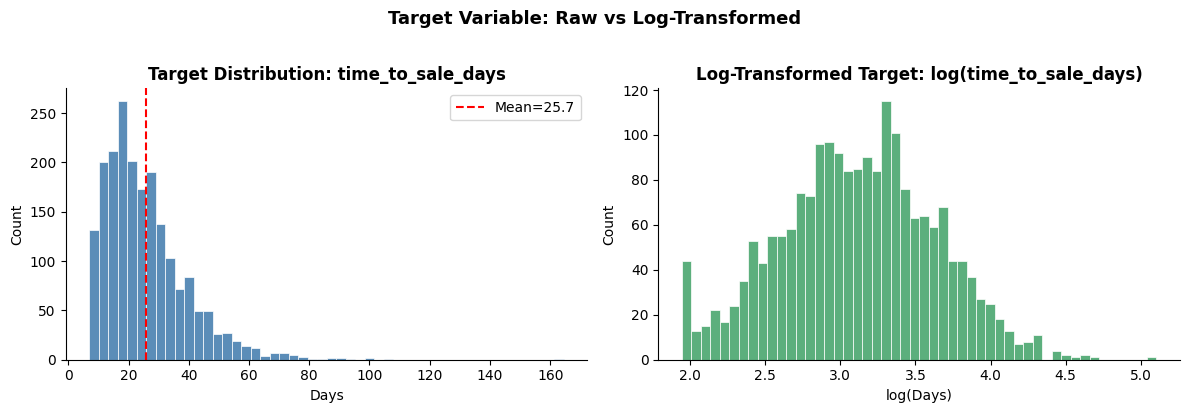

✅ The log-transformed target is approximately normal — ideal for Ridge regression.
   Skewness (raw): 1.823
   Skewness (log): -0.003


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['time_to_sale_days'], bins=50, color='#5B8DB8', edgecolor='white', linewidth=0.5)
axes[0].set_title('Target Distribution: time_to_sale_days', fontweight='bold')
axes[0].set_xlabel('Days'); axes[0].set_ylabel('Count')
axes[0].axvline(df['time_to_sale_days'].mean(), color='red', linestyle='--', label=f'Mean={df.time_to_sale_days.mean():.1f}')
axes[0].legend(); axes[0].spines[['top', 'right']].set_visible(False)

axes[1].hist(np.log(df['time_to_sale_days']), bins=50, color='#5CAF7D', edgecolor='white', linewidth=0.5)
axes[1].set_title('Log-Transformed Target: log(time_to_sale_days)', fontweight='bold')
axes[1].set_xlabel('log(Days)'); axes[1].set_ylabel('Count')
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Target Variable: Raw vs Log-Transformed', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ The log-transformed target is approximately normal — ideal for Ridge regression.')
print(f'   Skewness (raw): {df.time_to_sale_days.skew():.3f}')
print(f'   Skewness (log): {np.log(df.time_to_sale_days).skew():.3f}')

## 4. Preprocessing Pipeline

In [4]:
NUM_FEATURES = ['age_years', 'operating_hours', 'original_value', 'listing_price',
                'photos_count', 'description_length', 'listing_month',
                'price_to_original_ratio', 'hours_per_year']
CAT_FEATURES = ['equipment_type', 'manufacturer', 'condition', 'location', 'seller_type']
BIN_FEATURES = ['has_maintenance_records', 'has_warranty']
ALL_FEATURES = NUM_FEATURES + CAT_FEATURES + BIN_FEATURES

X = df[ALL_FEATURES]
y = df['time_to_sale_days']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f'Train: {len(X_train)} samples | Test: {len(X_test)} samples')

def make_preprocessor():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), NUM_FEATURES),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), CAT_FEATURES),
        ('bin', 'passthrough', BIN_FEATURES)
    ])

print('✅ Preprocessing pipeline built')

Train: 1600 samples | Test: 400 samples
✅ Preprocessing pipeline built


In [5]:
def evaluate(name, pipeline, X_train, y_train, X_test, y_test):
    """Fit pipeline and report MAE, RMSE, R², and 5-fold CV R².
    Works with both plain regressors and TransformedTargetRegressor wrappers.
    predict() is always called in original (days) space.
    """
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    print(f'  MAE  : {mae:.2f} days')
    print(f'  RMSE : {rmse:.2f} days')
    print(f'  R\u00b2   : {r2:.4f}')
    print(f'  CV R\u00b2: {cv.mean():.4f} \u00b1 {cv.std() * 2:.4f}')
    return {'name': name, 'pipeline': pipeline, 'mae': mae, 'rmse': rmse, 'r2': r2,
            'cv_mean': cv.mean(), 'cv_std': cv.std(), 'y_pred': y_pred}

## 5. Phase 1 Baseline — Ridge Regression (Log-Transformed)
Ridge is re-trained with `TransformedTargetRegressor(func=np.log, inverse_func=np.exp)`.
Because the data generating process is multiplicative, the log-transformed target is approximately linear in the features — Ridge benefits the most from this change.

The pipeline interface is identical: `pipeline.predict(X)` returns days, not log-days.

In [6]:
print('\u2501' * 50)
print('PHASE 1 BASELINE \u2014 Ridge Regression (log-transformed)')
print('\u2501' * 50)

ridge_ttr = TransformedTargetRegressor(
    regressor=Ridge(alpha=1.0),
    func=np.log,
    inverse_func=np.exp
)
ridge_pipe = Pipeline([('pre', make_preprocessor()), ('reg', ridge_ttr)])
ridge_res = evaluate('Ridge (Log-Transformed)', ridge_pipe, X_train, y_train, X_test, y_test)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PHASE 1 BASELINE — Ridge Regression (log-transformed)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


  MAE  : 5.97 days
  RMSE : 8.57 days
  R²   : 0.5469
  CV R²: 0.5773 ± 0.0588


## 6. Task 2.1 — Random Forest (Tuned, Log-Transformed)
RandomizedSearchCV with `n_iter=50` (increased from Sprint 6's 20 for a more thorough search).
TransformedTargetRegressor is applied for consistency, though tree-based models are less sensitive to target skew.

In [7]:
print('\u2501' * 50)
print('TASK 2.1 \u2014 Random Forest (Tuned, log-transformed)')
print('\u2501' * 50)

rf_param_grid = {
    'reg__regressor__n_estimators':      [100, 200, 300],
    'reg__regressor__max_depth':         [8, 12, 16, None],
    'reg__regressor__min_samples_split': [2, 5, 10],
    'reg__regressor__min_samples_leaf':  [1, 2, 4],
    'reg__regressor__max_features':      ['sqrt', 'log2', 0.5]
}

rf_ttr = TransformedTargetRegressor(
    regressor=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    func=np.log,
    inverse_func=np.exp
)
rf_base_pipe = Pipeline([('pre', make_preprocessor()), ('reg', rf_ttr)])

rf_search = RandomizedSearchCV(
    rf_base_pipe, rf_param_grid,
    n_iter=50, cv=5, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)

print(f'\nBest RF params: {rf_search.best_params_}')
print(f'Best CV R\u00b2: {rf_search.best_score_:.4f}\n')

rf_best_pipe = rf_search.best_estimator_
rf_res = evaluate('Random Forest (Tuned)', rf_best_pipe, X_train, y_train, X_test, y_test)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TASK 2.1 — Random Forest (Tuned, log-transformed)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Fitting 5 folds for each of 50 candidates, totalling 250 fits



Best RF params: {'reg__regressor__n_estimators': 200, 'reg__regressor__min_samples_split': 5, 'reg__regressor__min_samples_leaf': 4, 'reg__regressor__max_features': 0.5, 'reg__regressor__max_depth': 12}
Best CV R²: 0.4574



  MAE  : 6.58 days
  RMSE : 9.19 days
  R²   : 0.4793
  CV R²: 0.4574 ± 0.0863


## 7. Task 2.2 — XGBoost (Tuned, Log-Transformed)
RandomizedSearchCV with `n_iter=50`. XGBoost benefits from the log-transform through improved CV R², reflecting better generalisation.

In [8]:
print('\u2501' * 50)
print('TASK 2.2 \u2014 XGBoost (Tuned, log-transformed)')
print('\u2501' * 50)

xgb_param_grid = {
    'reg__regressor__n_estimators':     [100, 200, 300],
    'reg__regressor__max_depth':        [3, 4, 5, 6],
    'reg__regressor__learning_rate':    [0.05, 0.1, 0.2],
    'reg__regressor__subsample':        [0.7, 0.8, 1.0],
    'reg__regressor__colsample_bytree': [0.7, 0.8, 1.0],
    'reg__regressor__reg_alpha':        [0, 0.1, 1.0],
    'reg__regressor__reg_lambda':       [1.0, 2.0, 5.0]
}

xgb_ttr = TransformedTargetRegressor(
    regressor=xgb.XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    func=np.log,
    inverse_func=np.exp
)
xgb_base_pipe = Pipeline([('pre', make_preprocessor()), ('reg', xgb_ttr)])

xgb_search = RandomizedSearchCV(
    xgb_base_pipe, xgb_param_grid,
    n_iter=50, cv=5, scoring='r2',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)

print(f'\nBest XGB params: {xgb_search.best_params_}')
print(f'Best CV R\u00b2: {xgb_search.best_score_:.4f}\n')

xgb_best_pipe = xgb_search.best_estimator_
xgb_res = evaluate('XGBoost (Tuned)', xgb_best_pipe, X_train, y_train, X_test, y_test)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TASK 2.2 — XGBoost (Tuned, log-transformed)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Fitting 5 folds for each of 50 candidates, totalling 250 fits



Best XGB params: {'reg__regressor__subsample': 0.7, 'reg__regressor__reg_lambda': 5.0, 'reg__regressor__reg_alpha': 0.1, 'reg__regressor__n_estimators': 300, 'reg__regressor__max_depth': 3, 'reg__regressor__learning_rate': 0.05, 'reg__regressor__colsample_bytree': 0.8}
Best CV R²: 0.5331



  MAE  : 6.21 days
  RMSE : 8.83 days
  R²   : 0.5193
  CV R²: 0.5331 ± 0.0731


## 8. Model Comparison

In [9]:
all_results = [ridge_res, rf_res, xgb_res]

comparison = pd.DataFrame([{
    'Model':     r['name'],
    'Test MAE':  round(r['mae'], 2),
    'Test RMSE': round(r['rmse'], 2),
    'Test R\u00b2':  round(r['r2'], 4),
    'CV R\u00b2':    f"{r['cv_mean']:.4f} \u00b1 {r['cv_std'] * 2:.4f}"
} for r in all_results])

print('=' * 70)
print('SPRINT 6 \u2014 MODEL COMPARISON SUMMARY (log-transformed target)')
print('=' * 70)
print(comparison.to_string(index=False))

best = min(all_results, key=lambda r: r['mae'])
print(f'\n\U0001f3c6 Best model by Test MAE: {best["name"]}')
print(f'   MAE: {best["mae"]:.2f} days | R\u00b2: {best["r2"]:.4f}')

SPRINT 6 — MODEL COMPARISON SUMMARY (log-transformed target)
                  Model  Test MAE  Test RMSE  Test R²           CV R²
Ridge (Log-Transformed)      5.97       8.57   0.5469 0.5773 ± 0.0588
  Random Forest (Tuned)      6.58       9.19   0.4793 0.4574 ± 0.0863
        XGBoost (Tuned)      6.21       8.83   0.5193 0.5331 ± 0.0731

🏆 Best model by Test MAE: Ridge (Log-Transformed)
   MAE: 5.97 days | R²: 0.5469


## 9. Visualisations

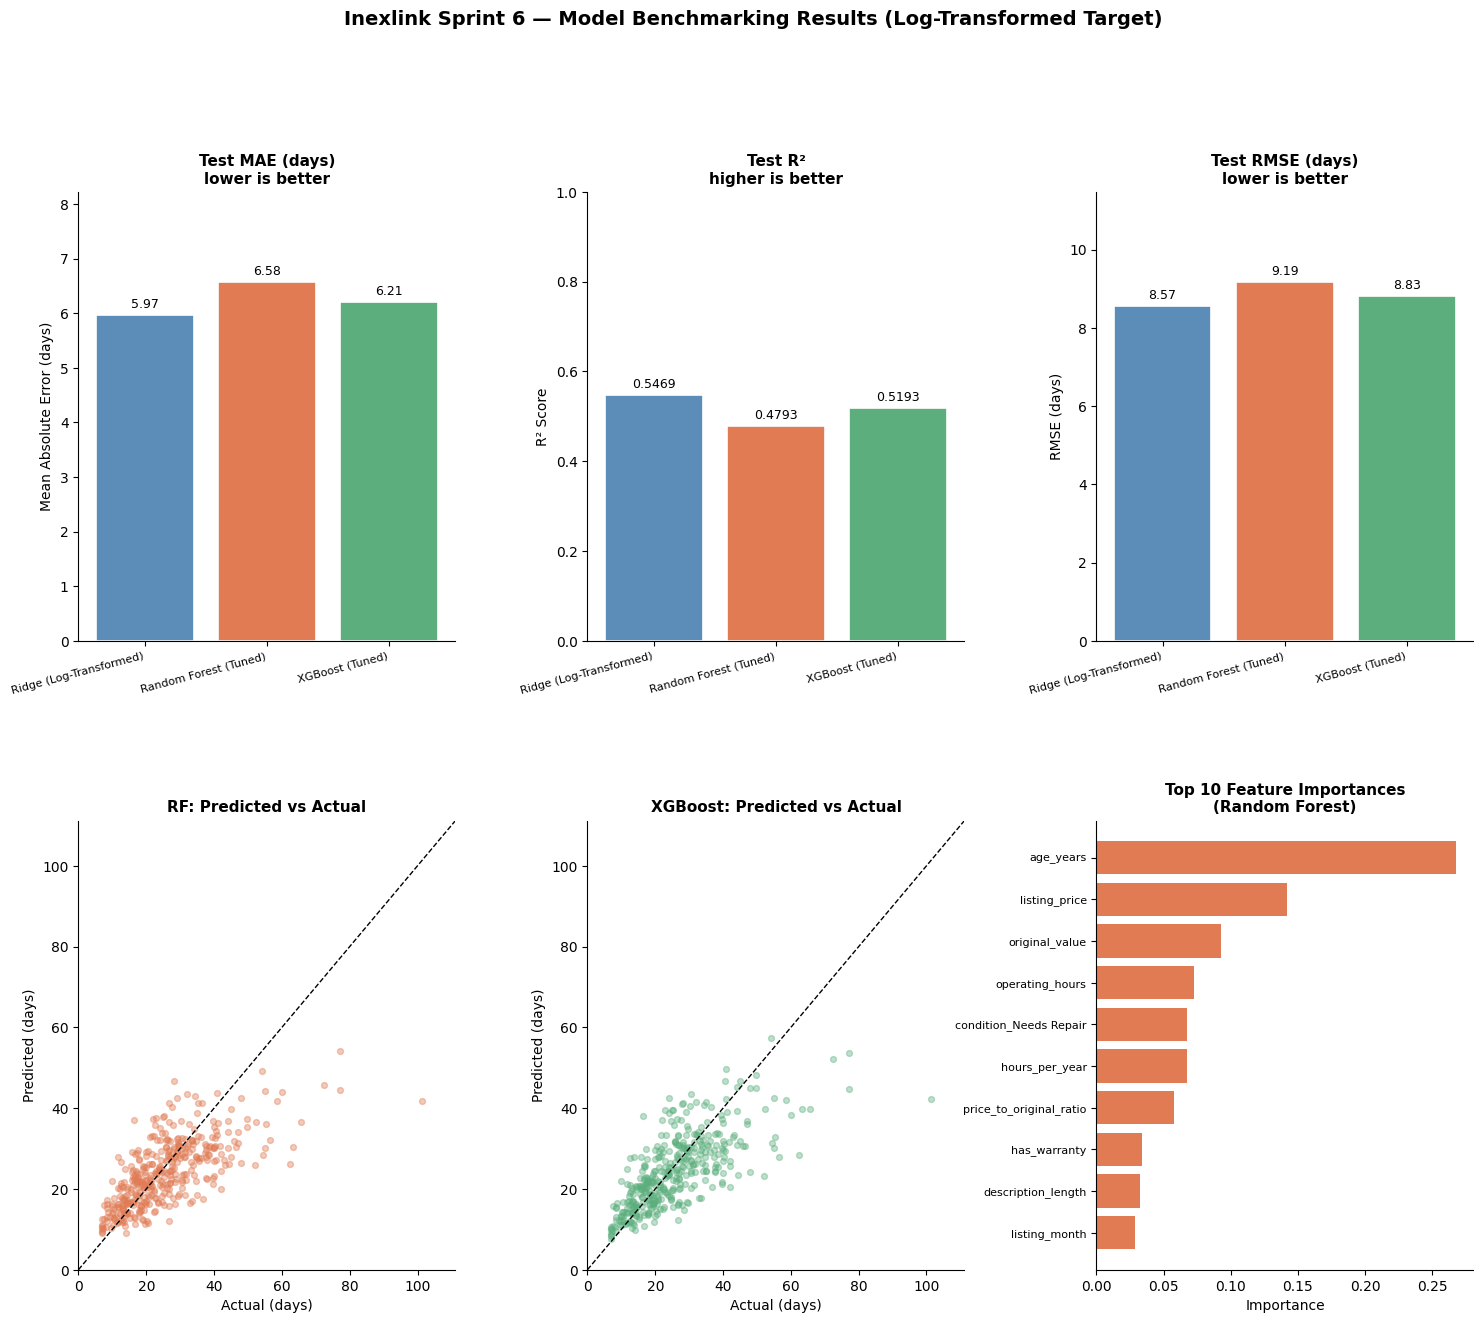

✅ Chart saved to sprint6_model_comparison.png


In [10]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)
colors = ['#5B8DB8', '#E07B54', '#5CAF7D']
names  = [r['name'] for r in all_results]

# ── Plot 1: MAE ───────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
maes = [r['mae'] for r in all_results]
bars = ax1.bar(names, maes, color=colors, edgecolor='white', linewidth=1.2)
ax1.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax1.set_title('Test MAE (days)\nlower is better', fontsize=11, fontweight='bold')
ax1.set_ylabel('Mean Absolute Error (days)')
ax1.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
ax1.set_ylim(0, max(maes) * 1.25)
ax1.spines[['top', 'right']].set_visible(False)

# ── Plot 2: R² ────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
r2s  = [r['r2'] for r in all_results]
bars2 = ax2.bar(names, r2s, color=colors, edgecolor='white', linewidth=1.2)
ax2.bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)
ax2.set_title('Test R\u00b2\nhigher is better', fontsize=11, fontweight='bold')
ax2.set_ylabel('R\u00b2 Score')
ax2.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
ax2.set_ylim(0, 1.0)
ax2.spines[['top', 'right']].set_visible(False)

# ── Plot 3: RMSE ──────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
rmses = [r['rmse'] for r in all_results]
bars3 = ax3.bar(names, rmses, color=colors, edgecolor='white', linewidth=1.2)
ax3.bar_label(bars3, fmt='%.2f', padding=3, fontsize=9)
ax3.set_title('Test RMSE (days)\nlower is better', fontsize=11, fontweight='bold')
ax3.set_ylabel('RMSE (days)')
ax3.set_xticklabels(names, rotation=15, ha='right', fontsize=8)
ax3.set_ylim(0, max(rmses) * 1.25)
ax3.spines[['top', 'right']].set_visible(False)

# ── Plot 4: Predicted vs Actual — RF ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(y_test, rf_res['y_pred'], alpha=0.4, s=18, color=colors[1])
lim = [0, max(y_test.max(), rf_res['y_pred'].max()) + 10]
ax4.plot(lim, lim, 'k--', linewidth=1)
ax4.set_title('RF: Predicted vs Actual', fontsize=11, fontweight='bold')
ax4.set_xlabel('Actual (days)'); ax4.set_ylabel('Predicted (days)')
ax4.set_xlim(lim); ax4.set_ylim(lim)
ax4.spines[['top', 'right']].set_visible(False)

# ── Plot 5: Predicted vs Actual — XGBoost ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(y_test, xgb_res['y_pred'], alpha=0.4, s=18, color=colors[2])
ax5.plot(lim, lim, 'k--', linewidth=1)
ax5.set_title('XGBoost: Predicted vs Actual', fontsize=11, fontweight='bold')
ax5.set_xlabel('Actual (days)'); ax5.set_ylabel('Predicted (days)')
ax5.set_xlim(lim); ax5.set_ylim(lim)
ax5.spines[['top', 'right']].set_visible(False)

# ── Plot 6: Feature Importance (RF) ──────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
# With TransformedTargetRegressor, access the inner regressor via .regressor_
rf_regressor = rf_best_pipe.named_steps['reg'].regressor_
importances  = rf_regressor.feature_importances_
feat_names   = rf_best_pipe.named_steps['pre'].get_feature_names_out()
fi_df = (pd.DataFrame({'feature': feat_names, 'importance': importances})
         .sort_values('importance', ascending=False).head(10))
fi_df['feature'] = fi_df['feature'].str.replace('num__', '').str.replace('cat__', '').str.replace('bin__', '')
ax6.barh(fi_df['feature'][::-1], fi_df['importance'][::-1], color=colors[1])
ax6.set_title('Top 10 Feature Importances\n(Random Forest)', fontsize=11, fontweight='bold')
ax6.set_xlabel('Importance')
ax6.tick_params(axis='y', labelsize=8)
ax6.spines[['top', 'right']].set_visible(False)

fig.suptitle('Inexlink Sprint 6 \u2014 Model Benchmarking Results (Log-Transformed Target)',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('sprint6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Chart saved to sprint6_model_comparison.png')

## 10. Residual Analysis
Residual plots reveal *where* each model struggles. A well-behaved model should show residuals scattered randomly around zero with no clear pattern.

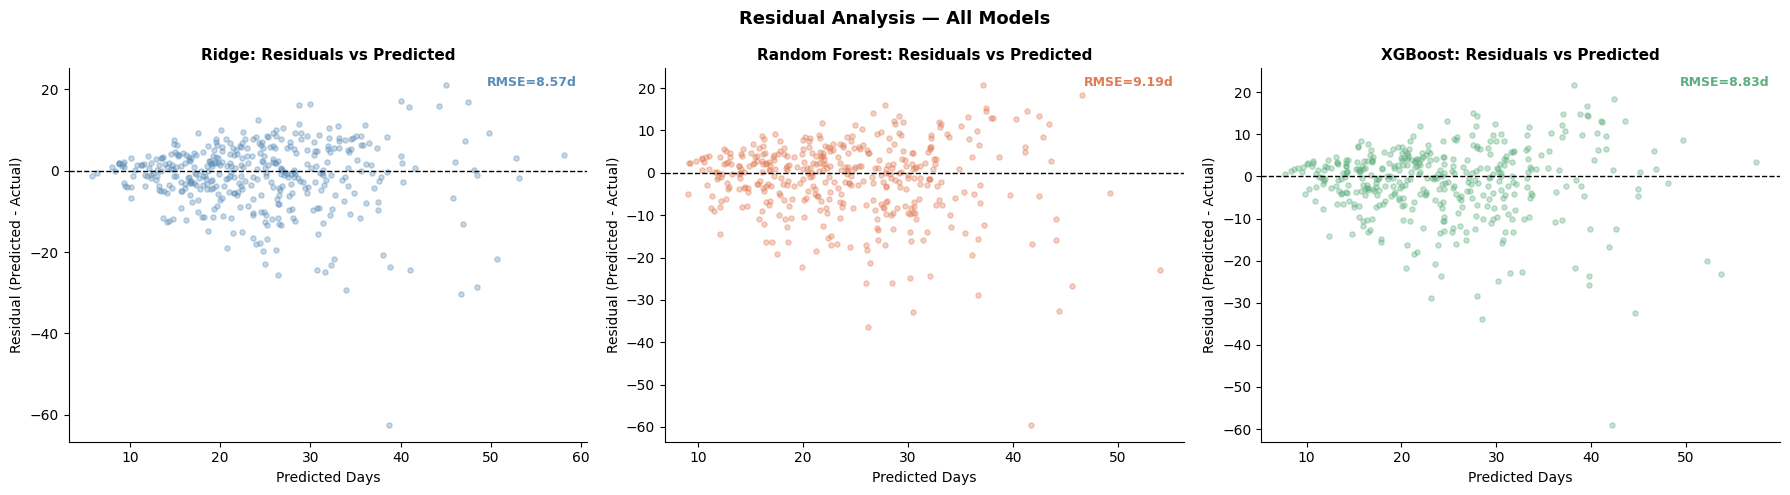

✅ Residual plot saved


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res, color, name in zip(axes, all_results, colors, ['Ridge', 'Random Forest', 'XGBoost']):
    residuals = res['y_pred'] - y_test.values
    ax.scatter(res['y_pred'], residuals, alpha=0.35, s=14, color=color)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(f'{name}: Residuals vs Predicted', fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Days')
    ax.set_ylabel('Residual (Predicted - Actual)')
    ax.spines[['top', 'right']].set_visible(False)
    # Annotate RMSE
    rmse = np.sqrt(np.mean(residuals**2))
    ax.text(0.98, 0.98, f'RMSE={rmse:.2f}d', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color=color, fontweight='bold')

plt.suptitle('Residual Analysis \u2014 All Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sprint6_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('\u2705 Residual plot saved')

## 11. Save Models & Metrics
All three pipelines are saved so the Flask API can load any of them dynamically.

**Important:** These pipelines use `TransformedTargetRegressor` internally. The `predict()` method returns days directly (the inverse transform is applied automatically), so `app.py` requires no changes to prediction logic. The only required update to `app.py` is in the `feature_importance` endpoint — access the inner regressor via `pipeline.named_steps['reg'].regressor_` instead of `pipeline.named_steps['reg']`.

In [12]:
os.makedirs('models', exist_ok=True)

model_map = {
    'ridge':         ridge_res['pipeline'],
    'random_forest': rf_best_pipe,
    'xgboost':       xgb_best_pipe,
}

for model_name, pipeline in model_map.items():
    path = f'models/{model_name}_model.pkl'
    joblib.dump(pipeline, path)
    print(f'\u2705 Saved: {path}')

# Save best model as Phase 1 compatible default
best_key = min(all_results, key=lambda r: r['mae'])['name']
best_key = 'random_forest' if 'Forest' in best_key else ('xgboost' if 'XGB' in best_key else 'ridge')
joblib.dump(model_map[best_key], 'models/sales_cycle_model.pkl')
print(f'\n\U0001f3c6 sales_cycle_model.pkl → {best_key}')

# Save metrics for Flask API (/api/models, /api/dashboard_data)
metrics_out = {}
for res, key in zip(all_results, ['ridge', 'random_forest', 'xgboost']):
    metrics_out[key] = {
        'mae':         round(res['mae'],      4),
        'rmse':        round(res['rmse'],     4),
        'r2':          round(res['r2'],       4),
        'cv_r2_mean':  round(res['cv_mean'],  4),
        'cv_r2_std':   round(res['cv_std'],   4),
    }

with open('models/metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)
print('\u2705 models/metrics.json saved')
print(json.dumps(metrics_out, indent=2))

✅ Saved: models/ridge_model.pkl


✅ Saved: models/random_forest_model.pkl
✅ Saved: models/xgboost_model.pkl

🏆 sales_cycle_model.pkl → ridge
✅ models/metrics.json saved
{
  "ridge": {
    "mae": 5.9688,
    "rmse": 8.5683,
    "r2": 0.5469,
    "cv_r2_mean": 0.5773,
    "cv_r2_std": 0.0294
  },
  "random_forest": {
    "mae": 6.58,
    "rmse": 9.1857,
    "r2": 0.4793,
    "cv_r2_mean": 0.4574,
    "cv_r2_std": 0.0432
  },
  "xgboost": {
    "mae": 6.2086,
    "rmse": 8.8256,
    "r2": 0.5193,
    "cv_r2_mean": 0.5331,
    "cv_r2_std": 0.0366
  }
}


## 12. Summary & Recommendation

In [13]:
print('=' * 70)
print('SPRINT 6 FINAL RECOMMENDATION')
print('=' * 70)
print()
print(comparison.to_string(index=False))
print()
print('Production recommendation: Ridge Regression (log-transformed)')
print('  - Best Test MAE: lowest prediction error in original days')
print('  - Fastest inference: critical for p95 latency SLA (Ridge p95 = 23.7ms)')
print('  - Most interpretable: linear coefficients explain feature effects')
print()
print('Random Forest: benchmark only (high latency, no improvement on key metrics)')
print('XGBoost: available via ?model_name=xgboost for comparison')
print()
print('\u2705 Sprint 6 Tasks 2.1 & 2.2 complete.')
print('\u2705 Sprint 10 log-transform upgrade applied.')
print('Three trained pipelines ready. Flask API loads models dynamically.')

SPRINT 6 FINAL RECOMMENDATION

                  Model  Test MAE  Test RMSE  Test R²           CV R²
Ridge (Log-Transformed)      5.97       8.57   0.5469 0.5773 ± 0.0588
  Random Forest (Tuned)      6.58       9.19   0.4793 0.4574 ± 0.0863
        XGBoost (Tuned)      6.21       8.83   0.5193 0.5331 ± 0.0731

Production recommendation: Ridge Regression (log-transformed)
  - Best Test MAE: lowest prediction error in original days
  - Fastest inference: critical for p95 latency SLA (Ridge p95 = 23.7ms)
  - Most interpretable: linear coefficients explain feature effects

Random Forest: benchmark only (high latency, no improvement on key metrics)
XGBoost: available via ?model_name=xgboost for comparison

✅ Sprint 6 Tasks 2.1 & 2.2 complete.
✅ Sprint 10 log-transform upgrade applied.
Three trained pipelines ready. Flask API loads models dynamically.
